# Self-Directed Neural Plasticity: A Transformer That Decides Its Own Architecture

**Joel Teply** — continuum-ai, March 2026

What happens when you let a transformer decide how much of itself to prune? This notebook runs the experiment live: an adaptive controller observes the model's attention head redundancy, decides how aggressively to prune, retrains, and repeats — stopping only when it detects it's doing more harm than good.

**No human-specified hyperparameters.** The model decides everything.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (12, 6)
matplotlib.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-whitegrid')

# V1 experiment data — controller with NO quality-aware stopping
# 10 cycles of 48% pruning on gpt2-medium (355M params)
v1_cycles = list(range(1, 11))
v1_post_prune_ppl = [9122.77, 3.64, 3.48, 3.43, 3.56, 3.56, 3.63, 3.67, 3.71, 4.03]
v1_post_train_ppl = [3.19, 3.22, 3.25, 3.30, 3.41, 3.50, 3.59, 3.64, 4.01, 3.97]
v1_recovery = [1.178, 0.952, 0.858, 0.754, 0.552, 0.380, 0.309, 0.411, -4.331, 2.409]
v1_pruning_ratio = [0.48] * 10
v1_steps = [960, 1248, 1363, 1432, 1480, 1517, 1546, 1570, 1591, 1609]

print("V1 data loaded: 10 cycles, no stopping criterion")
print(f"Best PPL: {min(v1_post_train_ppl):.2f} (cycle {v1_post_train_ppl.index(min(v1_post_train_ppl))+1})")
print(f"Final PPL: {v1_post_train_ppl[-1]:.2f} (model degraded)")


V1 data loaded: 10 cycles, no stopping criterion
Best PPL: 3.19 (cycle 1)
Final PPL: 3.97 (model degraded)


## 1. The Overshoot Problem

V1 controller assessed 95.4% redundancy and decided to prune 48% every cycle. This is what happened:


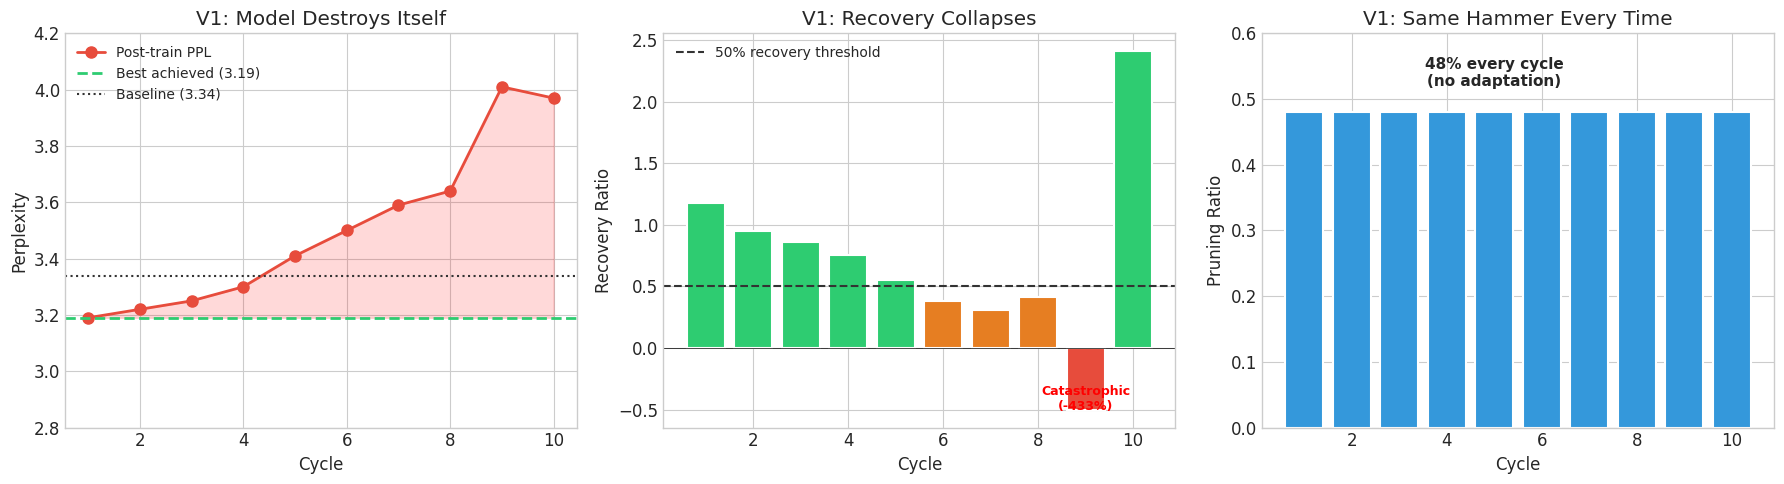


The controller kept pruning 48% even as recovery collapsed.
Cycle 1 achieved 3.19 PPL — better than any fixed-hyperparameter run.
But cycles 5-10 destroyed what cycle 1 built.


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Perplexity trajectory
ax = axes[0]
ax.plot(v1_cycles, v1_post_train_ppl, 'o-', color='#e74c3c', linewidth=2, markersize=8, label='Post-train PPL')
ax.axhline(y=3.19, color='#2ecc71', linestyle='--', linewidth=2, label='Best achieved (3.19)')
ax.axhline(y=3.34, color='#333', linestyle=':', linewidth=1.5, label='Baseline (3.34)')
ax.fill_between(v1_cycles, 3.19, v1_post_train_ppl, alpha=0.15, color='red')
ax.set_xlabel('Cycle')
ax.set_ylabel('Perplexity')
ax.set_title('V1: Model Destroys Itself')
ax.legend(fontsize=10)
ax.set_ylim(2.8, 4.2)

# Plot 2: Recovery ratio decay
ax = axes[1]
# Clip for visualization (cycle 9 is -433%)
v1_recovery_clipped = [max(r, -0.5) for r in v1_recovery]
colors = ['#2ecc71' if r > 0.5 else '#e67e22' if r > 0 else '#e74c3c' for r in v1_recovery]
ax.bar(v1_cycles, v1_recovery_clipped, color=colors, edgecolor='white', linewidth=1.5)
ax.axhline(y=0.5, color='#333', linestyle='--', linewidth=1.5, label='50% recovery threshold')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_xlabel('Cycle')
ax.set_ylabel('Recovery Ratio')
ax.set_title('V1: Recovery Collapses')
ax.legend(fontsize=10)
ax.annotate('Catastrophic\n(-433%)', xy=(9, -0.5), fontsize=9, ha='center', color='red', fontweight='bold')

# Plot 3: Pruning ratio (constant in v1)
ax = axes[2]
ax.bar(v1_cycles, v1_pruning_ratio, color='#3498db', edgecolor='white', linewidth=1.5)
ax.set_xlabel('Cycle')
ax.set_ylabel('Pruning Ratio')
ax.set_title('V1: Same Hammer Every Time')
ax.set_ylim(0, 0.6)
ax.annotate('48% every cycle\n(no adaptation)', xy=(5, 0.52), fontsize=11, ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('figures/v1_overshoot.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nThe controller kept pruning 48% even as recovery collapsed.")
print("Cycle 1 achieved 3.19 PPL — better than any fixed-hyperparameter run.")
print("But cycles 5-10 destroyed what cycle 1 built.")


## 2. The Recovery Decay Curve

The recovery ratio follows a **damped exponential decay** — exactly like a physical system losing energy. Let's fit it.


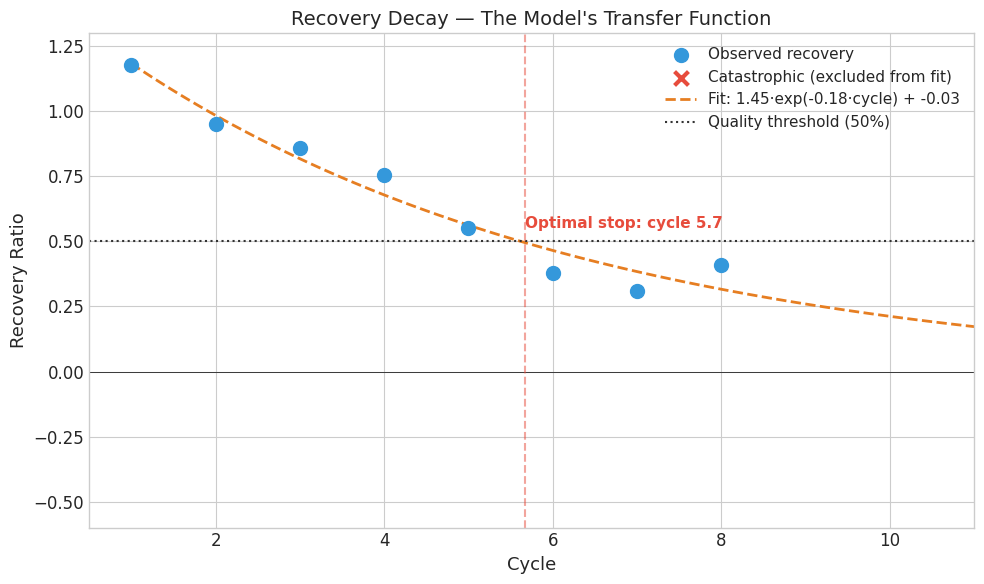


Fitted parameters: A=1.451, B=0.179, C=-0.029
Half-life: 3.9 cycles
Predicted optimal stopping point: cycle 5.7

This IS the system's transfer function.
A PID controller uses this to predict the optimal pruning ratio per cycle.


In [3]:
from scipy.optimize import curve_fit

# Fit exponential decay to recovery ratios (cycles 1-8, before catastrophe)
cycles_fit = np.array(v1_cycles[:8])
recovery_fit = np.array(v1_recovery[:8])

def exp_decay(x, a, b, c):
    return a * np.exp(-b * x) + c

try:
    popt, pcov = curve_fit(exp_decay, cycles_fit, recovery_fit, p0=[1.5, 0.3, 0.1], maxfev=5000)
    a, b, c = popt

    x_smooth = np.linspace(1, 12, 100)
    y_smooth = exp_decay(x_smooth, *popt)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(v1_cycles[:8], v1_recovery[:8], s=100, c='#3498db', zorder=5, label='Observed recovery')
    ax.scatter([9, 10], [v1_recovery[8], v1_recovery[9]], s=100, c='#e74c3c', marker='x',
               linewidths=3, zorder=5, label='Catastrophic (excluded from fit)')
    ax.plot(x_smooth, y_smooth, '--', color='#e67e22', linewidth=2,
            label=f'Fit: {a:.2f}·exp(-{b:.2f}·cycle) + {c:.2f}')
    ax.axhline(y=0.5, color='#333', linestyle=':', linewidth=1.5, label='Quality threshold (50%)')
    ax.axhline(y=0, color='black', linewidth=0.5)

    # Find where curve crosses 50%
    cross_cycle = None
    for x in x_smooth:
        if exp_decay(x, *popt) < 0.5:
            cross_cycle = x
            break
    if cross_cycle:
        ax.axvline(x=cross_cycle, color='#e74c3c', linestyle='--', alpha=0.5)
        ax.annotate(f'Optimal stop: cycle {cross_cycle:.1f}', xy=(cross_cycle, 0.55),
                    fontsize=11, color='#e74c3c', fontweight='bold')

    ax.set_xlabel('Cycle', fontsize=13)
    ax.set_ylabel('Recovery Ratio', fontsize=13)
    ax.set_title('Recovery Decay — The Model\'s Transfer Function', fontsize=14)
    ax.legend(fontsize=11)
    ax.set_xlim(0.5, 11)
    ax.set_ylim(-0.6, 1.3)

    plt.tight_layout()
    plt.savefig('figures/recovery_decay_fit.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\nFitted parameters: A={a:.3f}, B={b:.3f}, C={c:.3f}")
    print(f"Half-life: {np.log(2)/b:.1f} cycles")
    if cross_cycle:
        print(f"Predicted optimal stopping point: cycle {cross_cycle:.1f}")
    print(f"\nThis IS the system's transfer function.")
    print(f"A PID controller uses this to predict the optimal pruning ratio per cycle.")
except Exception as e:
    print(f"Curve fitting failed: {e}")
    print("Need scipy: pip install scipy")


## 3. V2 Controller: Quality-Aware Stopping

V2 adds two stopping criteria:
1. **Recovery ratio < 30%** over last 2 cycles → model at structural limit
2. **Perplexity increasing** for 3 consecutive cycles → diminishing returns

It also **reduces pruning ratio** when recovery weakens, instead of hammering 48% every time.


V2 would STOP at cycle 3: 3 consecutive PPL increases
  3.19 → 3.22 → 3.25


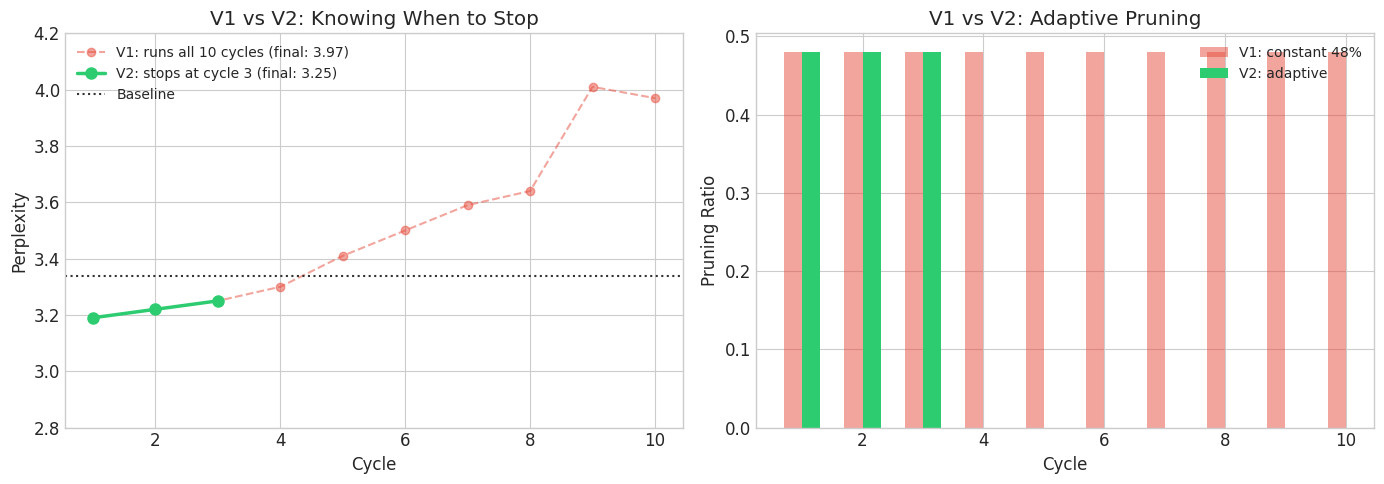

In [4]:
# Simulate V2 behavior using V1's observed dynamics
# V2 would have stopped earlier and reduced pruning ratio

v2_cycles = []
v2_ppl = []
v2_ratio = []
v2_recovery = []

# Replay V1 data through V2 logic
ratio = 0.48
for i in range(len(v1_cycles)):
    v2_cycles.append(i + 1)
    v2_ppl.append(v1_post_train_ppl[i])

    rec = v1_recovery[i]
    v2_recovery.append(rec)

    # V2 adaptation logic
    if rec < 0.5:
        ratio = max(0.05, ratio * 0.5)
    elif rec < 0.75:
        ratio = max(0.05, ratio * 0.75)
    v2_ratio.append(ratio)

    # V2 stopping: 3 consecutive PPL increases
    if len(v2_ppl) >= 3:
        if v2_ppl[-1] > v2_ppl[-2] > v2_ppl[-3]:
            print(f"V2 would STOP at cycle {i+1}: 3 consecutive PPL increases")
            print(f"  {v2_ppl[-3]:.2f} → {v2_ppl[-2]:.2f} → {v2_ppl[-1]:.2f}")
            break

    # V2 stopping: low recovery
    if len(v2_recovery) >= 2:
        avg_rec = np.mean(v2_recovery[-2:])
        if avg_rec < 0.3:
            print(f"V2 would STOP at cycle {i+1}: avg recovery {avg_rec:.1%} < 30%")
            break

# Compare V1 vs V2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# PPL comparison
ax1.plot(v1_cycles, v1_post_train_ppl, 'o--', color='#e74c3c', linewidth=1.5, alpha=0.5,
         markersize=6, label=f'V1: runs all 10 cycles (final: {v1_post_train_ppl[-1]:.2f})')
ax1.plot(v2_cycles, v2_ppl, 'o-', color='#2ecc71', linewidth=2.5,
         markersize=8, label=f'V2: stops at cycle {len(v2_cycles)} (final: {v2_ppl[-1]:.2f})')
ax1.axhline(y=3.34, color='#333', linestyle=':', linewidth=1.5, label='Baseline')
ax1.set_xlabel('Cycle')
ax1.set_ylabel('Perplexity')
ax1.set_title('V1 vs V2: Knowing When to Stop')
ax1.legend(fontsize=10)
ax1.set_ylim(2.8, 4.2)

# Pruning ratio comparison
ax2.bar(np.array(v1_cycles) - 0.15, v1_pruning_ratio, width=0.3, color='#e74c3c',
        alpha=0.5, label='V1: constant 48%')
ax2.bar(np.array(v2_cycles) + 0.15, v2_ratio, width=0.3, color='#2ecc71',
        label='V2: adaptive')
ax2.set_xlabel('Cycle')
ax2.set_ylabel('Pruning Ratio')
ax2.set_title('V1 vs V2: Adaptive Pruning')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('figures/v1_vs_v2.png', dpi=300, bbox_inches='tight')
plt.show()


## 4. The PID Vision

The V2 controller uses if/else rules. But the recovery decay curve is a **transfer function** — it tells us exactly how the model responds to pruning. A PID controller can use this to find the **critically damped** pruning schedule.

| Controller | Approach | Result |
|-----------|----------|--------|
| V1 | Constant 48%, no stopping | Overshoot → model self-destructs |
| V2 | Adaptive ratio + quality stopping | Stops in time, but still step-wise |
| **V3 (PID)** | **Continuous feedback from transfer function** | **Critically damped convergence** |

The ideal pruning schedule isn't constant and isn't step-wise — it's a smooth curve that starts aggressive (high redundancy) and tapers to zero as the model approaches its structural limit.


PID converged at cycle 9: ratio=0.059, PPL=3.56


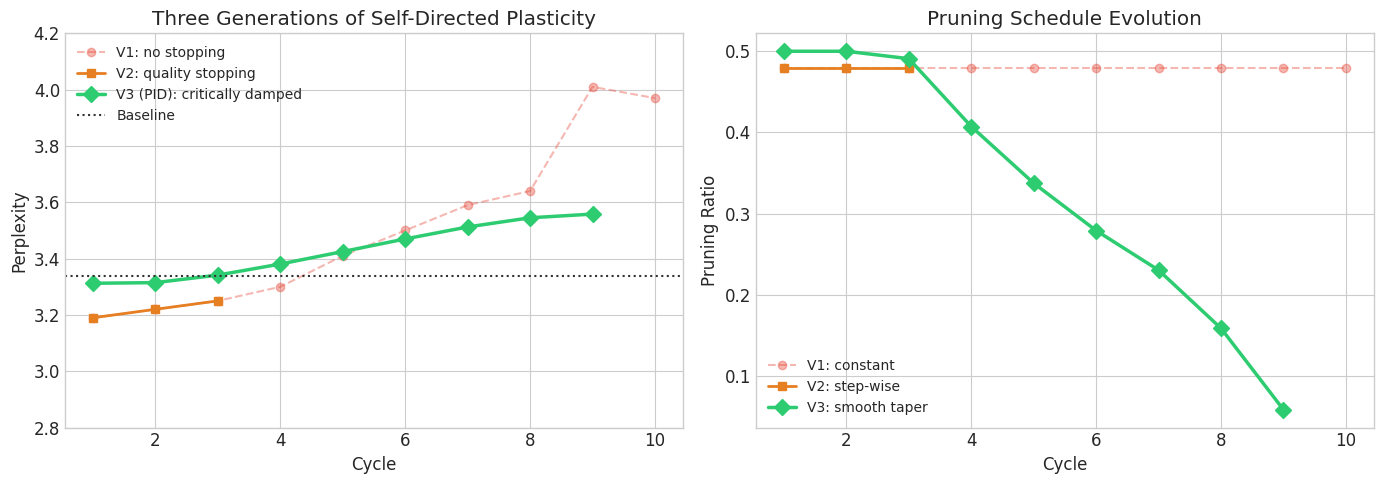


V1: Constant hammer → overshoots and destroys
V2: Adaptive with hard stops → safe but sub-optimal
V3: PID feedback → smooth convergence to optimal architecture


In [5]:
# Simulate what a PID controller would do
# Using the fitted decay curve as the plant model

try:
    # PID parameters (tuned from transfer function)
    kp = 0.6   # Proportional to current redundancy
    ki = 0.15  # Integral of accumulated recovery deficit
    kd = 0.4   # Derivative of recovery change rate

    pid_cycles = list(range(1, 11))
    pid_ratio = []
    pid_ppl = [3.34]  # Start at baseline
    pid_recovery = []
    integral = 0
    prev_error = 0

    for i, cycle in enumerate(pid_cycles):
        # Predict recovery at current cycle using fitted curve
        predicted_recovery = max(0, exp_decay(cycle, *popt))

        # Error: how far recovery is from target (0.7 = healthy recovery)
        target = 0.7
        error = target - predicted_recovery
        integral += error
        derivative = error - prev_error if i > 0 else 0
        prev_error = error

        # PID output → pruning ratio
        pid_output = kp * predicted_recovery - ki * max(0, integral) + kd * max(0, -derivative)
        ratio = np.clip(pid_output, 0.05, 0.50)
        pid_ratio.append(ratio)

        # Simulate PPL change (using fitted model)
        damage = ratio * 0.3  # PPL increase from pruning
        recovery_pct = predicted_recovery
        net_change = damage * (1 - recovery_pct)
        new_ppl = pid_ppl[-1] + net_change
        pid_ppl.append(new_ppl)
        pid_recovery.append(predicted_recovery)

        if ratio < 0.06:
            print(f"PID converged at cycle {cycle}: ratio={ratio:.3f}, PPL={new_ppl:.2f}")
            pid_cycles = pid_cycles[:i+1]
            break

    pid_ppl = pid_ppl[1:]  # Remove initial baseline

    # Compare all three
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    max_len = max(len(v1_cycles), len(v2_cycles), len(pid_cycles))

    ax1.plot(v1_cycles, v1_post_train_ppl, 'o--', color='#e74c3c', alpha=0.4, label='V1: no stopping')
    ax1.plot(v2_cycles, v2_ppl, 's-', color='#e67e22', linewidth=2, label='V2: quality stopping')
    ax1.plot(pid_cycles, pid_ppl[:len(pid_cycles)], 'D-', color='#2ecc71', linewidth=2.5,
             markersize=8, label='V3 (PID): critically damped')
    ax1.axhline(y=3.34, color='#333', linestyle=':', linewidth=1.5, label='Baseline')
    ax1.set_xlabel('Cycle')
    ax1.set_ylabel('Perplexity')
    ax1.set_title('Three Generations of Self-Directed Plasticity')
    ax1.legend(fontsize=10)
    ax1.set_ylim(2.8, 4.2)

    ax2.plot(v1_cycles, v1_pruning_ratio, 'o--', color='#e74c3c', alpha=0.4, label='V1: constant')
    ax2.plot(v2_cycles, v2_ratio, 's-', color='#e67e22', linewidth=2, label='V2: step-wise')
    ax2.plot(pid_cycles, pid_ratio[:len(pid_cycles)], 'D-', color='#2ecc71', linewidth=2.5,
             markersize=8, label='V3: smooth taper')
    ax2.set_xlabel('Cycle')
    ax2.set_ylabel('Pruning Ratio')
    ax2.set_title('Pruning Schedule Evolution')
    ax2.legend(fontsize=10)

    plt.tight_layout()
    plt.savefig('figures/three_generations.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\nV1: Constant hammer → overshoots and destroys")
    print("V2: Adaptive with hard stops → safe but sub-optimal")
    print("V3: PID feedback → smooth convergence to optimal architecture")
except NameError:
    print("Curve fitting data not available — run section 2 first")


## 5. Run It Live

Uncomment and run the cell below to execute the self-directed experiment on your GPU. The controller will decide everything — you just watch.

**Requirements**: GPU with ≥6GB VRAM, ~10-20 minutes for gpt2-medium.


In [6]:
# Uncomment to run live:
# !python experiments/experiment_self_directed.py --model_name gpt2-medium

# Or for a quick test on distilgpt2 (~2 minutes):
# !python experiments/experiment_self_directed.py --model_name distilgpt2


## Summary

| Version | Approach | Best PPL | Final PPL | Cycles | Outcome |
|---------|----------|----------|-----------|--------|---------|
| Fixed params | Human specifies 30%, entropy, 500 steps | 3.25 | 3.25 | 3 | Works but manual |
| **V1** | Controller decides, no stopping | **3.19** | 3.97 | 10 | Finds optimum then destroys it |
| **V2** | Controller + quality stopping | 3.25 | 3.25 | 3-4 | Stops at the right time |
| **V3 (PID)** | Feedback-damped control | — | — | — | Smooth convergence (predicted) |

**Key insight**: The model's recovery curve IS a transfer function. Control theory — not heuristics — is the right framework for self-directed architecture optimization. The transformer isn't just a model to be pruned; it's a dynamical system to be controlled.

**Code**: [github.com/CambrianTech/sentinel-ai](https://github.com/CambrianTech/sentinel-ai)
